In [1]:
import pandas as pd                   
import numpy as np
import matplotlib.pyplot as plt       
import seaborn as sns   
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split   
from sklearn.linear_model import LogisticRegression     
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, precision_recall_curve
)   
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Objective
My goal is to build a post-approval Probability of Default (PD) Model that can answer: **"Given that the borrower is already approved and currently active, what is the probability that they will default going forward based on their first 30 days of repayment behavior?**

This PD model is helpful for the company because it allows proactive risk management by identifying borrowers likely to default early, enabling better capital allocation, reducing losses, improving portfolio quality, and strengthening regulatory compliance

## 1. Exploratory Data Analysis(EDA)

Here I explore loan, clarity and payment data to uncover signals of different features.

In [2]:
loan = pd.read_csv("loan.csv") 
loan.head()

,loanId,anon_ssn,payFrequency,apr,applicationDate,originated,originatedDate,nPaidOff,approved,isFunded,loanStatus,loanAmount,originallyScheduledPaymentAmount,state,leadType,leadCost,fpStatus,clarityFraudId,hasCF
0,LL-I-07399092,beff4989be82aab4a5b47679216942fd,B,360.0,2016-02-23T17:29:01.940000,False,NaN,0.0,False,0,Withdrawn Application,500.0,978.27,IL,bvMandatory,6,NaN,5669ef78e4b0c9d3936440e6,1
1,LL-I-06644937,464f5d9ae4fa09ece4048d949191865c,B,199.0,2016-01-19T22:07:36.778000,True,2016-01-20T15:49:18.846000,0.0,True,1,Paid Off Loan,3000.0,6395.19,CA,prescreen,0,Checked,569eb3a3e4b096699f685d64,1
2,LL-I-10707532,3c174ae9e2505a5f9ddbff9843281845,B,590.0,2016-08-01T13:51:14.709000,False,NaN,0.0,False,0,Withdrawn Application,400.0,1199.45,MO,bvMandatory,3,NaN,579eab11e4b0d0502870ef2f,1
3,LL-I-02272596,9be6f443bb97db7e95fa0c281d34da91,B,360.0,2015-08-06T23:58:08.880000,False,NaN,0.0,False,0,Withdrawn Application,500.0,1074.05,IL,bvMandatory,3,NaN,555b1e95e4b0f6f11b267c18,1
4,LL-I-09542882,63b5494f60b5c19c827c7b068443752c,B,590.0,2016-06-05T22:31:34.304000,False,NaN,0.0,False,0,Rejected,350.0,814.37,NV,bvMandatory,3,NaN,5754a91be4b0c6a2bf424772,1


In [3]:
print("Column                              % Missing")
print(loan.isnull().mean() * 100)
print("Loan's shape before:", loan.shape)

Column                              % Missing
loanId                               0.044315
anon_ssn                             0.000000
payFrequency                         0.220363
apr                                  0.678920
applicationDate                      0.000000
originated                           0.000000
originatedDate                      92.029525
nPaidOff                             0.004155
approved                             0.000000
isFunded                             0.000000
loanStatus                           0.067684
loanAmount                           0.389488
originallyScheduledPaymentAmount     0.000000
state                                0.022850
leadType                             0.000000
leadCost                             0.000000
fpStatus                            91.046458
clarityFraudId                      38.081332
hasCF                                0.000000
dtype: float64
Loan's shape before: (577682, 19)


- Some loans do not have a `clarityFraudId`, which indicates that they did not go through the Clarity underwriting process. This missingness is informative because whether or not a loan had a Clarity check may itself correlate with default risk. The dataset also includes the `hasCF `feature, which encodes this information, so we can retain these loans in the analysis without dropping them.
- Some columns have a lot of missing values because the loan is not approved thus, no data (e.g. `originatedDate` and `fpStatus`) so I'm gonna leave them as is due to structural missingness.
- For any column with <1% missing, I'm dropping them because the percentage is tiny and almost negligible.

In [4]:
date_cols = ["applicationDate", "originatedDate"]
for col in date_cols:
    loan[col] = pd.to_datetime(loan[col], errors="coerce")

cleaned_loan = loan.dropna(subset=["loanId","payFrequency", "apr", "applicationDate", "nPaidOff", "loanStatus", "loanAmount", "state"])
cleaned_loan.shape
print("Loan's shape after:",cleaned_loan.shape)

Loan's shape after: (571680, 19)


**b. Clarity Underwriting Data**

In [5]:
clarity = pd.read_csv("clarity_underwriting_variables.csv", low_memory=False)
clarity.head()

,.underwritingdataclarity.clearfraud.clearfraudinquiry.thirtydaysago,.underwritingdataclarity.clearfraud.clearfraudinquiry.twentyfourhoursago,.underwritingdataclarity.clearfraud.clearfraudinquiry.oneminuteago,.underwritingdataclarity.clearfraud.clearfraudinquiry.onehourago,.underwritingdataclarity.clearfraud.clearfraudinquiry.ninetydaysago,.underwritingdataclarity.clearfraud.clearfraudinquiry.sevendaysago,.underwritingdataclarity.clearfraud.clearfraudinquiry.tenminutesago,.underwritingdataclarity.clearfraud.clearfraudinquiry.fifteendaysago,.underwritingdataclarity.clearfraud.clearfraudinquiry.threesixtyfivedaysago,.underwritingdataclarity.clearfraud.clearfraudindicator.inquiryonfilecurrentaddressconflict,...,.underwritingdataclarity.clearfraud.clearfraudidentityverification.phonematchtypedescription,.underwritingdataclarity.clearfraud.clearfraudidentityverification.overallmatchresult,.underwritingdataclarity.clearfraud.clearfraudidentityverification.phonetype,.underwritingdataclarity.clearfraud.clearfraudidentityverification.ssndobreasoncode,.underwritingdataclarity.clearfraud.clearfraudidentityverification.ssnnamereasoncode,.underwritingdataclarity.clearfraud.clearfraudidentityverification.nameaddressreasoncode,.underwritingdataclarity.clearfraud.clearfraudidentityverification.ssndobmatch,.underwritingdataclarity.clearfraud.clearfraudidentityverification.overallmatchreasoncode,clearfraudscore,underwritingid
0,8.0,2.0,2.0,2.0,8.0,2.0,2.0,5.0,10.0,False,...,(M) Mobile Phone,partial,NaN,NaN,NaN,A8,match,6.0,871.0,54cbffcee4b0ba763e43144d
1,5.0,2.0,2.0,2.0,11.0,2.0,2.0,4.0,21.0,True,...,(M) Mobile Phone,partial,NaN,NaN,NaN,NaN,match,11.0,397.0,54cc0408e4b0418d9a7f78af
2,9.0,4.0,2.0,3.0,10.0,8.0,2.0,9.0,25.0,False,...,(M) Mobile Phone,match,NaN,NaN,NaN,NaN,match,1.0,572.0,54cc0683e4b0418d9a80adb6
3,3.0,2.0,2.0,2.0,9.0,2.0,2.0,2.0,9.0,False,...,(M) Mobile Phone,partial,NaN,NaN,NaN,NaN,match,11.0,838.0,54cc0780e4b0ba763e43b74a
4,5.0,5.0,2.0,2.0,6.0,5.0,2.0,5.0,6.0,False,...,(M) Mobile Phone,match,NaN,NaN,NaN,NaN,match,1.0,768.0,54cc1d67e4b0ba763e445b45


In [6]:
print("Column                                                                                                 % Missing")
print(clarity.isnull().mean() * 100)
print("Clarity's shape before:", clarity.shape)

Column                                                                                                 % Missing
.underwritingdataclarity.clearfraud.clearfraudinquiry.thirtydaysago                                     0.004020
.underwritingdataclarity.clearfraud.clearfraudinquiry.twentyfourhoursago                                0.004020
.underwritingdataclarity.clearfraud.clearfraudinquiry.oneminuteago                                      0.004020
.underwritingdataclarity.clearfraud.clearfraudinquiry.onehourago                                        0.004020
.underwritingdataclarity.clearfraud.clearfraudinquiry.ninetydaysago                                     0.004020
.underwritingdataclarity.clearfraud.clearfraudinquiry.sevendaysago                                      0.004020
.underwritingdataclarity.clearfraud.clearfraudinquiry.tenminutesago                                     0.004020
.underwritingdataclarity.clearfraud.clearfraudinquiry.fifteendaysago                            

- For columns with high missingness (>50%), I'm dropping them because they're almost all missing, unlikely to add value, and hard to impute reliably.
- As for columns with low-to-moderate missing values, I impute numeric features using the median and categorical features using the mode. This approach preserves most of the data while providing complete inputs for the model.

In [7]:
threshold = 0.5
cols_to_drop = clarity.columns[clarity.isna().mean() > threshold]
cleaned_clarity = clarity.drop(columns=cols_to_drop)

for col in cleaned_clarity.columns:
    if cleaned_clarity[col].dtype in ("float64", "int64"):
        cleaned_clarity[col] = cleaned_clarity[col].fillna(cleaned_clarity[col].median())
    else:
        cleaned_clarity[col] = cleaned_clarity[col].fillna(cleaned_clarity[col].mode()[0])

print("Clarity's shape after:", cleaned_clarity.shape)

Clarity's shape after: (49752, 45)


**Payment Data**
- I noticed that pandas interpreting "None" as null in `paymentStatus`, but it's actually informative, so I make sure to treat it as a category, not missing.
- Since the percentage for missing `paymentDate` is low (~2.5% missing), I'll just drop these rows because I need actual payment dates to compute features.
- As for `paymentReturnCode` with ~95% missingness, it's a structural missingness due to only rejected payment have such code.

In [8]:
payment = pd.read_csv("payment.csv")
print("Column               % Missing")
print(payment.isnull().mean() * 100)
print("Before:", payment.shape)

payment["paymentDate"] = pd.to_datetime(payment["paymentDate"], errors="coerce")
payment['paymentStatus'] = payment['paymentStatus'].fillna("None")

ach_groups = {
    "insufficient_funds": ["R01", "R09"],
    "account_closed": ["R02", "R03", "R16", "R20"],
    "invalid_account_info": ["R04", "R17", "R21", "R22"],
    "unauthorized": ["R05", "R07", "R10", "R29"],
    "payment_stopped": ["R08", "R23"],
    "administrative": ["R06", "R11", "R12", "R13", "R14", "R15", "R24", "R31", "R33"]
}

def map_ach_group(code):
    if pd.isna(code):
        return "none"
    for group, codes in ach_groups.items():
        if code in codes:
            return group
    return "other"

payment.loc[:, "ach_return_group"] = payment["paymentReturnCode"].apply(map_ach_group)

Column               % Missing
loanId                0.000000
installmentIndex      0.000000
isCollection          0.000000
paymentDate           0.000000
principal             0.000000
fees                  0.000000
paymentAmount         0.000000
paymentStatus        23.798313
paymentReturnCode    95.425784
dtype: float64
Before: (689364, 9)


I aggregate the payment dataset to a single row per `loanId` because the PD model must operate at the loan/applicant level, not the payment-event level. Raw payment records would duplicate loans and leak post-approval information. By summarizing payments (e.g., total principal paid, number of payments, collections) and adding simple timing features (e.g., first payment date, payment gaps), I keep the data at the correct granularity while still capturing meaningful past repayment behavior for modeling.

For a behavioral 30-day PD model, the features must only reflect borrower actions within the first 30 days after funding, so the dataset is filtered to include only those first 30 days of activity before aggregation.

In [9]:
loan_dates = loan[["loanId", "originatedDate"]].drop_duplicates()
payment = payment.merge(loan_dates, on="loanId", how="left")

payment["days_from_origination"] = (payment["paymentDate"] - payment["originatedDate"]).dt.days
payment_30d = payment[payment["days_from_origination"] <= 30].copy()
payment_30d = payment_30d.sort_values(["loanId", "paymentDate"])

failed_statuses = ["Rejected", "Rejected awaiting retry"]
payment_30d["failed_payment"] = payment_30d["paymentStatus"].isin(failed_statuses).astype(int)
payment_30d["cancelled_payment"] = (payment_30d["paymentStatus"] =="Cancelled").astype(int)

payment_30d["days_between"] = payment_30d.groupby("loanId")["paymentDate"].diff().dt.days

payment_agg = payment_30d.groupby("loanId").agg(
    total_principal=("principal", "sum"),
    total_fees=("fees", "sum"),
    total_payment=("paymentAmount", "sum"),
    num_payments=("paymentAmount", "count"),
    num_collections=("isCollection", "sum"),
    num_failed_payments=("failed_payment", "sum"),
    num_cancelled_payments=("cancelled_payment", "sum"),
    originatedDate=("originatedDate", "first"),
    first_payment_date=("paymentDate", "min"),
    last_payment_date=("paymentDate", "max"),
    avg_days_between=("days_between", "mean"),
    max_days_between=("days_between", "max")
).reset_index()

ach_agg = payment_30d.pivot_table(
    index="loanId",
    columns="ach_return_group",
    values="paymentReturnCode",
    aggfunc="count",
    fill_value=0
).reset_index()

ach_agg.columns = ["loanId" if col=="loanId" else f"num_{col}_returns" for col in ach_agg.columns]

payment_agg = payment_agg.merge(ach_agg, on="loanId", how="left")

Here I calculate how many failed payments occurred after the initial 30‑day window, which is be helpful for default estimation later.

In [10]:
failed_statuses = ["Rejected", "Rejected awaiting retry"]
payment["failed_payment_full"] = payment["paymentStatus"].isin(failed_statuses).astype(int)

payment_full_agg = payment.groupby("loanId").agg(
    num_failed_payments_full=("failed_payment_full", "sum")
).reset_index()

payment_agg = payment_agg.merge(payment_full_agg, on="loanId", how="left")
payment_agg["num_failed_after_30d"] = (payment_agg["num_failed_payments_full"] - payment_agg["num_failed_payments"]).clip(lower=0)
payment_agg.head()

,loanId,total_principal,total_fees,total_payment,num_payments,num_collections,num_failed_payments,num_cancelled_payments,originatedDate,first_payment_date,...,num_account_closed_returns,num_administrative_returns,num_insufficient_funds_returns,num_invalid_account_info_returns,num_none_returns,num_other_returns,num_payment_stopped_returns,num_unauthorized_returns,num_failed_payments_full,num_failed_after_30d
0,LL-I-00000021,48.77,290.45,339.22,2,0,0,0,2014-12-03 03:12:58.466,2014-12-19 05:00:00,...,0,0,0,0,0,0,0,0,1,1
1,LL-I-00000238,27.20,263.00,290.20,2,0,0,0,2014-12-04 17:26:49.668,2014-12-15 05:00:00,...,0,0,0,0,0,0,0,0,1,1
2,LL-I-00000355,34.00,236.70,270.70,3,0,1,1,2014-12-03 03:12:55.376,2014-12-11 05:00:00,...,1,0,0,0,0,0,0,0,1,0
3,LL-I-00000419,23.80,202.51,226.31,2,0,1,0,2014-12-03 03:12:52.218,2014-12-11 05:00:00,...,0,0,1,0,0,0,0,0,2,1
4,LL-I-00000614,75.21,433.62,508.83,3,0,1,1,2014-12-03 03:12:53.335,2014-12-19 05:00:00,...,1,0,0,0,0,0,0,0,1,0


Here I add ACH codes for those with rejected payment.

In [11]:
ach_cols = [c for c in payment_agg.columns if c.startswith("num_") and c.endswith("_returns")]
payment_agg[ach_cols] = payment_agg[ach_cols].fillna(0)

cols_to_drop = ["num_none_returns", "num_other_returns"]
payment_agg = payment_agg.drop(columns=[col for col in cols_to_drop if col in payment_agg.columns])

Next, I'm merging first 30 days of payment data with loan and clarity data. Now I have full dataset of initial 30 days for model training later.

In [12]:
loan_clarity = cleaned_loan.merge(cleaned_clarity, left_on="clarityFraudId",right_on="underwritingid", how="left")
pd_df = loan_clarity.merge(payment_agg, on="loanId", how="left")
pd_df["originatedDate"] = pd_df["originatedDate_x"]
pd_df = pd_df.drop(columns=["originatedDate_x", "originatedDate_y"])
pd_df = pd_df[pd_df["isFunded"] == 1].copy()
print("PD's shape:", pd_df.shape)
pd_df.head()

PD's shape: (38928, 83)


,loanId,anon_ssn,payFrequency,apr,applicationDate,originated,nPaidOff,approved,isFunded,loanStatus,...,max_days_between,num_account_closed_returns,num_administrative_returns,num_insufficient_funds_returns,num_invalid_account_info_returns,num_payment_stopped_returns,num_unauthorized_returns,num_failed_payments_full,num_failed_after_30d,originatedDate
1,LL-I-06644937,464f5d9ae4fa09ece4048d949191865c,B,199.0,2016-01-19 22:07:36.778,True,0.0,True,1,Paid Off Loan,...,14.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2016-01-20 15:49:18.846
15,LL-I-12263369,accf40708233e8b7d05fcb89d5a9c081,B,475.0,2016-11-28 19:54:22.982,True,2.0,True,1,New Loan,...,14.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2016-11-29 20:30:40.640
33,LL-I-17826953,7529d29c9d943cc55bc71a85d9c6b7a3,W,645.0,2017-03-01 15:55:41.823,True,0.0,True,1,New Loan,...,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2017-03-01 16:15:13.016
47,LL-I-16519347,bc9fa73468acf18cb968a3a6a3c4697c,S,490.0,2017-01-31 17:48:17.381,True,2.0,True,1,Paid Off Loan,...,13.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2017-01-31 18:00:14.520
54,LL-I-11506719,10cefd11d41612b032fd9cd2debe32dc,B,590.0,2016-08-27 09:08:05.442,True,0.0,True,1,Paid Off Loan,...,14.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2016-08-29 15:05:04.014


### Target Variable Exploration 

Here I'm looking for potential features with strong predictive signals for default risk. Given the limited set of available indicators, I’m operationally defining default as any loan with one or more failed payments after 30 days.

In [13]:
pd_df["default"] = (pd_df["num_failed_after_30d"] > 0).astype(int)
print("Overall default rate:", pd_df["default"].mean() * 100, "%")

Overall default rate: 31.871660501438555 %


Given this approval rate, the dataset is imbalanced so this requires special handling during modeling. To address the imbalance, I plan to implement the following strategies:
- Use class weights in the model
- Apply stratified sampling for the train/test split

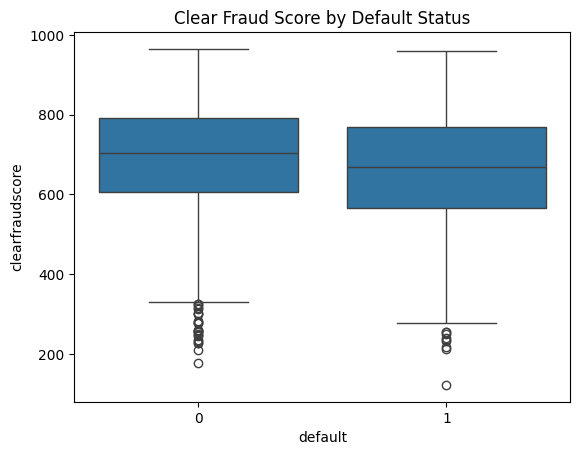

In [14]:
sns.boxplot(data=pd_df, x="default", y="clearfraudscore")
plt.title("Clear Fraud Score by Default Status")
plt.show()

This confirms that "higher score suggest lower default probability", so this means clear fraud score could have a strong predictive signal for PD Model.

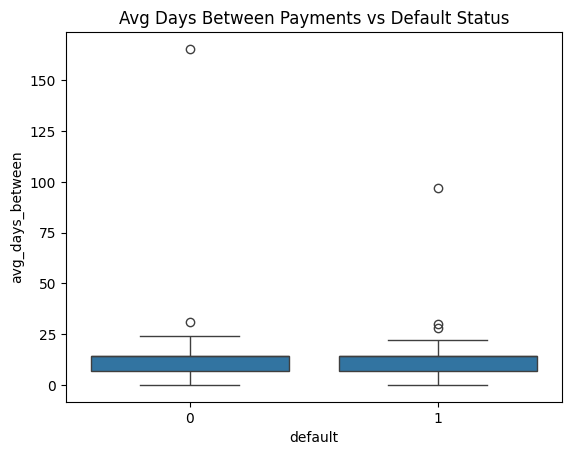

In [15]:
sns.boxplot(data=pd_df, x="default", y="avg_days_between")
plt.title("Avg Days Between Payments vs Default Status")
plt.show()

Since this dataset only observes the first 30 days of repayment behavior, we can't draw strong conclusions from `avg_days_between` alone. However, it is logically plausible that borrowers who default tend to have longer gaps between payments, so it may serve as a meaningful early indicator for predicting default risk.

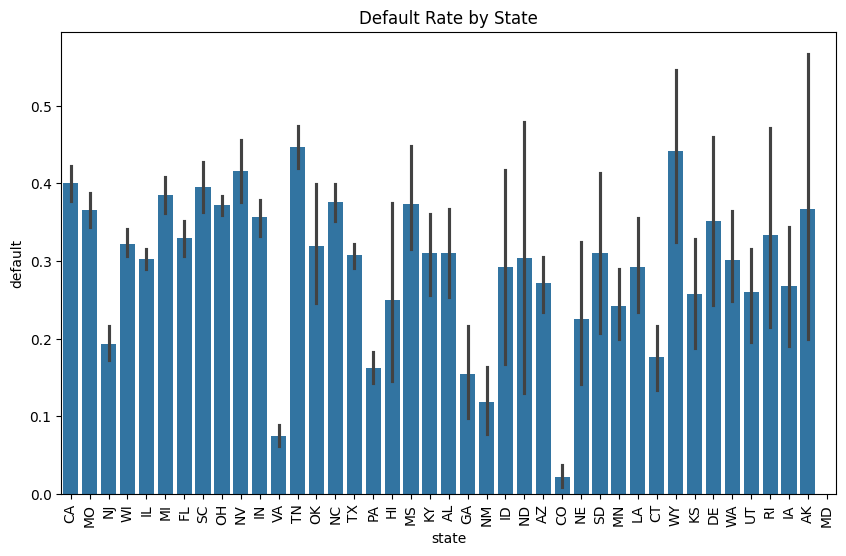

In [16]:
plt.figure(figsize=(10,6))
sns.barplot(data=pd_df, x="state", y="default")
plt.xticks(rotation=90)
plt.title("Default Rate by State")
plt.show()

Maryland (MD) has 0% default rate, which is because it has small sample size. I'll check the sample size in all these states to examine whether similar anomalies exist elsewhere.

Maryland sample size: 1


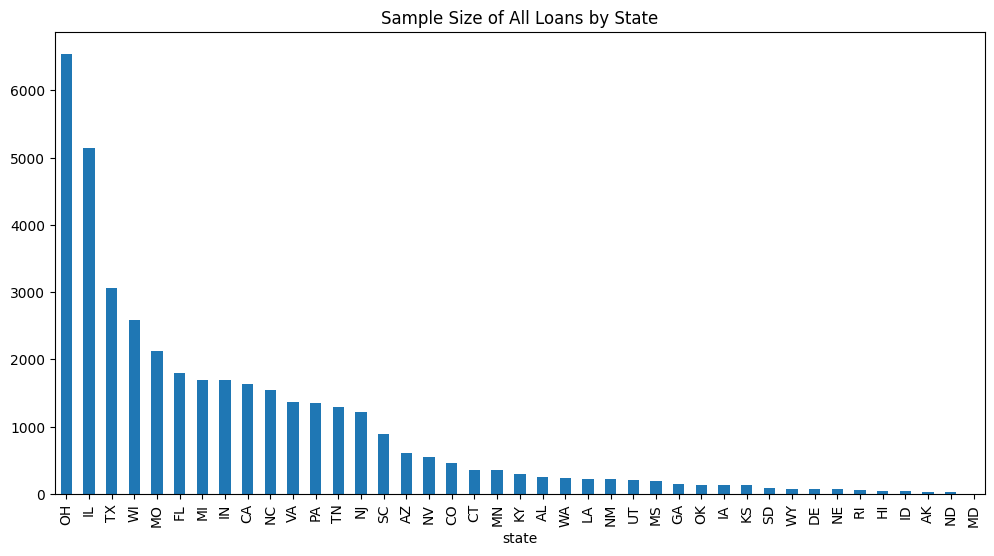

In [17]:
state_counts = pd_df["state"].value_counts()

md_count = state_counts.get("MD", 0)
print(f"Maryland sample size: {md_count}")

state_counts.plot(kind="bar", figsize=(12, 6), title="Sample Size of All Loans by State")
plt.show()

As seen above, the sample sizes are uneven across states for PD dataset. Including state could lead the model to learn unstable or non-generalizable patterns, especially when the sample sizes are uneven across states. So, I'll exclude `state` from the model to mitigate the risk of overfitting to such anomalies and enhance model robustness.

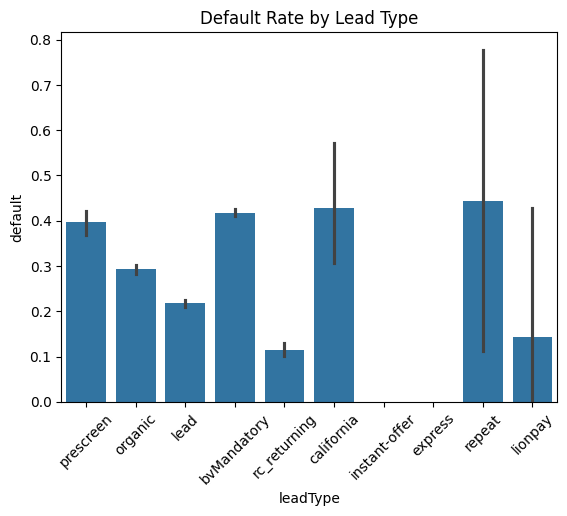

In [18]:
sns.barplot(data=pd_df, x="leadType", y="default")
plt.xticks(rotation=45)
plt.title("Default Rate by Lead Type")
plt.show()

Similar patterns happen here where "instant-offer", "express" have 0% default rate. I'll again check the sample size to see if there are more data anomalies.

Instant Offer sample size: 9
Express sample size: 16


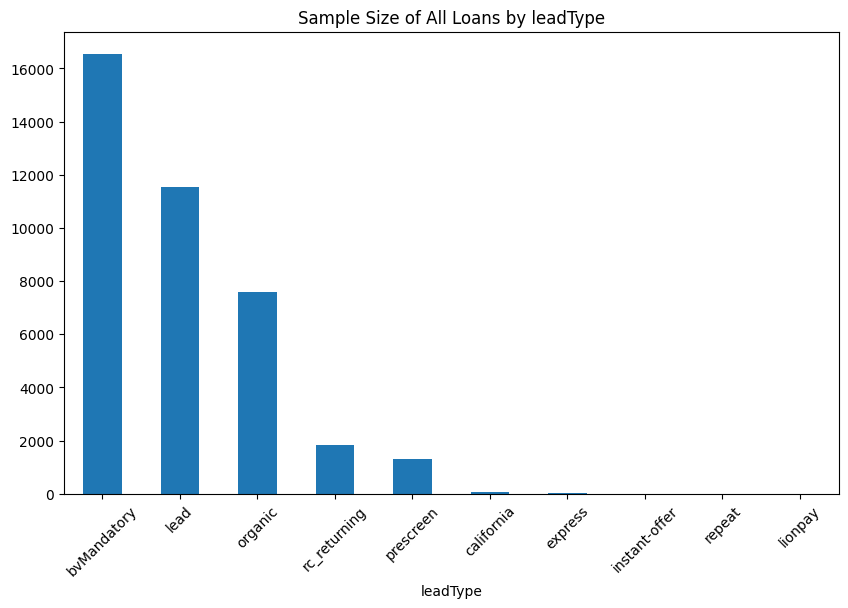

In [19]:
leadtype_counts = pd_df["leadType"].value_counts()

io_count = leadtype_counts.get("instant-offer", 0)
exp_count = leadtype_counts.get("express", 0)
print(f"Instant Offer sample size: {io_count}")
print(f"Express sample size: {exp_count}")

leadtype_counts.plot(kind="bar", figsize=(10,6), title="Sample Size of All Loans by leadType")
plt.xticks(rotation=45)
plt.show()

In [20]:
rare_leadtypes = leadtype_counts[leadtype_counts < 100].index.tolist()
pd_df["leadType"] = pd_df["leadType"].apply(lambda x: "other" if x in rare_leadtypes else x)
print(pd_df["leadType"].value_counts())

leadType
bvMandatory     16552
lead            11549
organic          7591
rc_returning     1839
prescreen        1307
other              90
Name: count, dtype: int64


The default rate chart shows some lead types are riskier than other so this can be strong signal foor PD's model feature. However, lead types with very low sample size (e.g., lionpay, repeat, etc.) may introduce noise of overfitting. To work around this, I'm grouping rare types into an "other" bucket (e.g., if count < 100).

payFrequency
B    22763
W    10238
M     2876
S     2623
I      428
Name: count, dtype: int64


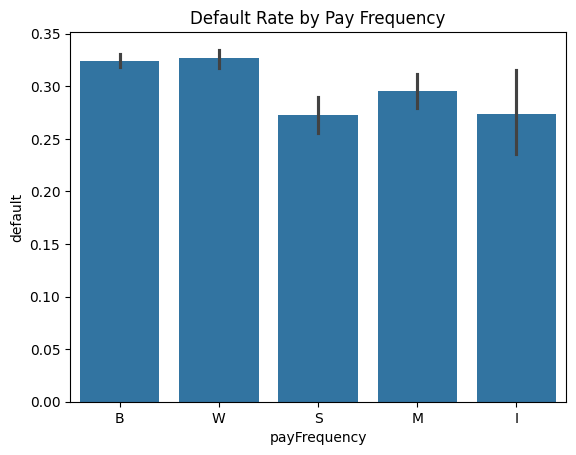

In [21]:
print(pd_df["payFrequency"].value_counts())
sns.barplot(data=pd_df, x="payFrequency", y="default")
plt.title("Default Rate by Pay Frequency")
plt.show()

At first glance, it seems counterintuitive that applicants with irregular pay frequency (I) exhibit the lowest default rate. However, given that this group only includes 428 samples, it's likely that only the most creditworthy irregular applicants were approved, resulting in an artificially low observed default rate. To validate this hypothesis and assess whether the pattern holds across other dimensions, I’ll next examine how pay frequency interacts with other features such as clearFraudScore, and loan amount in relation to default behavior.

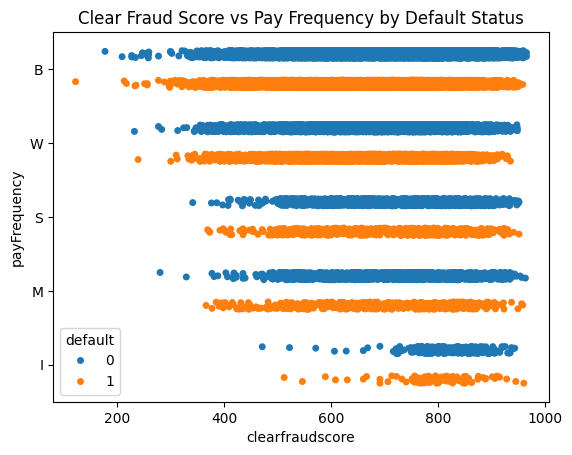

In [22]:
sns.stripplot(data=pd_df, x="clearfraudscore", y="payFrequency", hue="default", dodge=True)
plt.title("Clear Fraud Score vs Pay Frequency by Default Status")
plt.show()

This plot shows that most borrowers with Irregular pay frequency have higher clear fraud score (>750) than other types of borrowers. So this confirm that only most creditwothy irregular applicants are approved and they are less likely to default. This interaction between pay frequency and fraud score not only explains their lower observed default rate but also offers a valuable feature for modeling default risk.

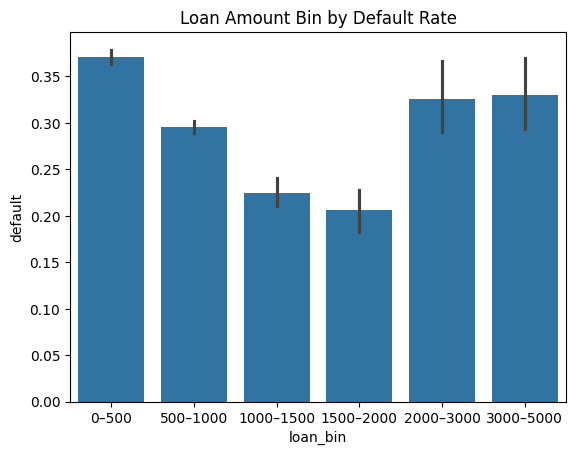

In [23]:
bins = [0, 500, 1000, 1500, 2000, 3000, 5000]
labels = ["0–500", "500–1000", "1000–1500", "1500–2000", "2000–3000", "3000–5000"]
pd_df["loan_bin"] = pd.cut(pd_df["loanAmount"], bins=bins, labels=labels, right=False)

sns.barplot(data=pd_df, x="loan_bin", y="default", dodge=True)
plt.title("Loan Amount Bin by Default Rate")
plt.show()

Default rates dip for mid-range loans but spike at extremes, suggesting a U-shaped risk curve. I'll proceed to check its interaction with other feature like payFrequency.

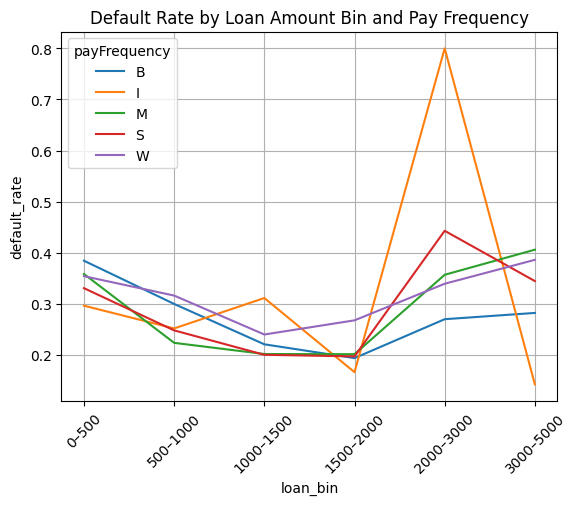

In [24]:
grouped = (
    pd_df.groupby(["loan_bin", "payFrequency"], observed=True)
    .agg(default_rate=("default", "mean"), count=("default", "size"))
    .reset_index()
)

sns.lineplot(data=grouped, x="loan_bin", y="default_rate", hue="payFrequency")
plt.title("Default Rate by Loan Amount Bin and Pay Frequency")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Loan amount of 1000-2000 has lower default rate in general. Default rates for borrowers with irregular pay frequency spike in mid-to-high loan bins but drop at the highest tier, suggesting a non-linear interaction between income regularity and loan size that may reflect underwriting thresholds or borrower self-selection.

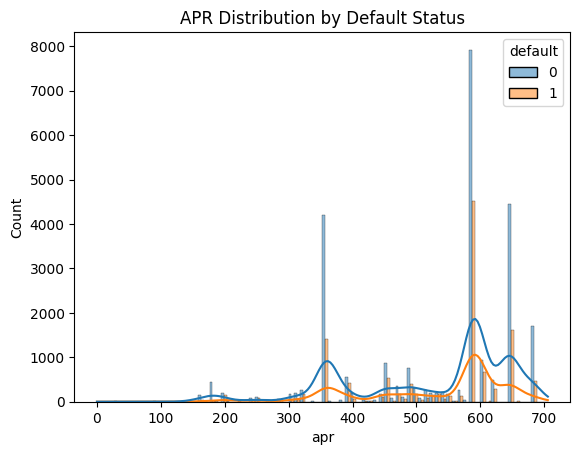

In [25]:
sns.histplot(data=pd_df, x="apr",hue="default", multiple="dodge", kde=True)
plt.title("APR Distribution by Default Status")
plt.show()

The default and non-default curves look similar within the same APR bands. This suggests that APR alone isn't a strong discriminator of default risk in those regions so model interactions are needed to capture nonlinear effects.

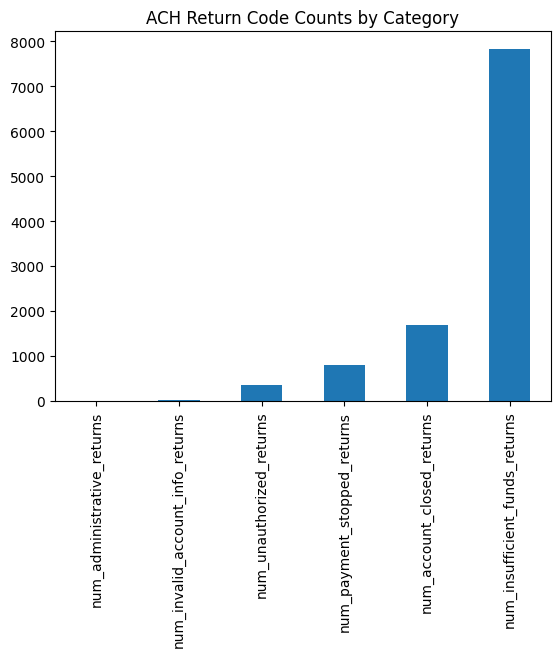

In [26]:
ach_cols = [c for c in pd_df.columns if c.startswith("num_") and c.endswith("_returns")]

pd_df[ach_cols].sum().sort_values().plot(kind='bar')
plt.title("ACH Return Code Counts by Category")
plt.show()

This examines why the payments are rejected with the ACH Return Code with insufficient funds as the dominant cause, which indicate high default risk. However only rejected payment has ACH code so we can't use to predict if the applcant has suffienct funding. 

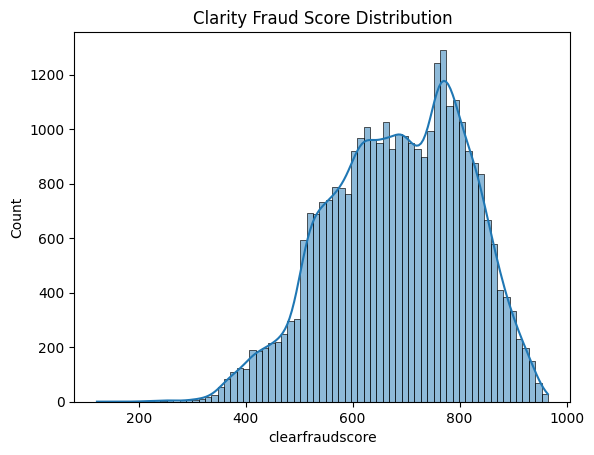

In [27]:
sns.histplot(pd_df["clearfraudscore"], kde=True)
plt.title("Clarity Fraud Score Distribution")
plt.show()

The fraud score distribution is right-skewed, with most applicants concentrated around high scores (>750) indicating lower default risk.

## Feature Engineering

Here I created features for PD Model based on the EDA findings. When engineering features for this modeling exercise, I tried to interpret each attribute in the context of the underlying loan problem: **predicting how applicants will behave financially and whether they are likely to repay.**

Below is the reasoning behind each group of engineered features.

In [28]:
df_features = pd_df.copy()

**1. Payment Behavior Features**

These features capture borrower behavior after loan disbursement. While not all are observable at approval time, they help clarify repayment patterns and will be excluded from early-stage default prediction. Key counstructs include:

- `payment_success_rate`: This is more as a proxy for behavioral consistency rather than just "did they fail to pay".
- `has_collections`: Collections are a clear signal of distress or financial breakdown. This feature becomes especially informative when combined with fraud or irregular payment signals.
- `payment_to_loan_ratio`: This approximates whether the borrower is repaying proportional to what they owe.

In [29]:
df_features['payment_success_rate'] = (
    df_features['num_payments']-df_features['num_failed_payments']) / df_features['num_payments'].replace(0, np.nan)
df_features['payment_success_rate'] = df_features['payment_success_rate'].fillna(0)

df_features['has_collections'] = (df_features['num_collections'] > 0).astype(int)

df_features['payment_to_loan_ratio'] = (df_features['total_payment'] / df_features['loanAmount']).clip(0, 1).fillna(0)

These days-between-payments features capture whether a borrower behaves according to their claimed pay frequency. If a borrower says they will pay bi-weekly but payments come every 45 days, this mismatch may suggest financial instability and can be used as irregular payment indicator. For example, borrowers with very long gaps in payment (e.g., more than a month or max_days_between > 40) exhibit higher risk.

In [30]:
if 'avg_days_between' in df_features.columns:
    df_features['days_between_bin'] = pd.cut(
        df_features['avg_days_between'], 
        bins=[0, 14, 21, 28, 40, np.inf],
        labels=['weekly', 'biweekly', 'monthly', 'irregular', 'very_irregular']
    )
    df_features['is_very_irregular_payment'] = (df_features['avg_days_between'] > 40).astype(int)

if 'max_days_between' in df_features.columns:
    df_features['log_max_days_between'] = np.log1p(df_features['max_days_between'])

**2. Loan Structure Features**

These mainly focus on how the design of the loan influences repayment difficulty. Categorizing loan amount helps detect non‑linear risk patterns, as very small or very large loans have distinct profiles. In addition, the `scheduled_payment_to_loan_ratio` highlights affordability stress, since higher ratios signal a heavier monthly burden relative to the loan amount. Finally, loan amount transformations such as log and squared terms enable the model to capture diminishing or increasing sensitivity to loan size, ensuring that subtle variations in borrower exposure are reflected in the risk analysis.

In [31]:
df_features["loan_amount_bin"] = pd.cut(
    df_features["loanAmount"],
    bins=[0, 500, 1000, 1500, 2000, 3000, 5000, 10000],
    labels=["very low", "low", "medium_low", "medium", "medium_high", "high", "very high"]
)

df_features['scheduled_payment_to_loan_ratio'] = (
    df_features['originallyScheduledPaymentAmount'] / df_features['loanAmount']
)

df_features["loan_amount_log"] = np.log1p(df_features["loanAmount"])
df_features["loan_amount_squared"] = df_features["loanAmount"] ** 2

** 3. Fraud-Related Features**

These features capture signals of fraud risk and recent credit activity. While not all loans have been through underwriting, this can bla bla bla
Key contructs:
- `fraud_risk_level`: Transforms the raw fraud score into categorical buckets, making it easier to analyze non‑linear effects and interpret interactions with other features
- `has_fraud_indicators`: Flags any presence of suspicious activity.
- `high_fraud_indicators` Identifies more severe signals.
- `has_credit_inquiries`: Measures recent credit‑seeking behavior since credit inquiries often reflect financial stress for credit, which is predictive of repayment difficulty.

In [32]:
df_features["fraud_risk_level"] = pd.qcut(
    df_features["clearfraudscore"],
    q=4,
    labels=["high_risk", "medium_risk", "low_risk", "very_low_risk"],
    duplicates="drop"
)

fraud_indicator_col = '.underwritingdataclarity.clearfraud.clearfraudindicator.totalnumberoffraudindicators'
df_features['total_fraud_indicators'] = df_features[fraud_indicator_col].fillna(0)
df_features['has_fraud_indicators'] = (df_features['total_fraud_indicators'] > 0).astype(int)
df_features['high_fraud_indicators'] = (df_features['total_fraud_indicators'] >= 3).astype(int)

inquiry_cols = [col for col in df_features.columns if 'clearfraudinquiry' in col]
if inquiry_cols:
    df_features['total_recent_inquiries'] = df_features[inquiry_cols].sum(axis=1)
    df_features['has_recent_inquiries'] = (df_features['total_recent_inquiries'] > 0).astype(int)

**4. Temporal Features**

If a borrower delays their first payment, it may signal difficulty adjusting to repayment schedule or early warning for default.
`time_to_first_payment` helps understand borrower behavior relative to loan origination.

In [33]:
# Temporal features
df_features['time_to_first_payment'] = (df_features['first_payment_date'] - df_features['applicationDate']).dt.days
df_features['time_to_first_payment'] = df_features['time_to_first_payment'].fillna(0)

**5. Interaction Features**

These help capture real-world relationships:

- Irregular Pay × Clear Fraud Score: Irregular pay frequency combined with high fraud signals is more concerning than either alone.
- Irregular Pay × Loan Amount: A large loan and irregular income is a higher risk scenario.
- Fraud × Loan Amount: The same fraud score carries different risk at different loan sizes.
- APR × Loan Amount: Captures debt burden from pricing.

In [34]:
df_features['is_irregular_pay'] = (df_features['payFrequency'] == 'I').astype(int)

df_features['irregular_x_fraud'] = (df_features['is_irregular_pay'] * df_features['clearfraudscore'])
df_features['irregular_x_loan'] = (df_features['is_irregular_pay'] * df_features['loanAmount'])
df_features['freq_consistency'] = df_features['is_irregular_pay'] * df_features.get('is_very_irregular_payment', 0)
df_features["loan_burden"] = (df_features["originallyScheduledPaymentAmount"] * df_features["total_payment"]) / df_features["loanAmount"]
df_features['fraud_x_loan'] = df_features['clearfraudscore'] * df_features['loanAmount']
df_features["apr_x_loan"] = (df_features["apr"] / 100) * (df_features["loanAmount"] / 1000)

**Other Features**

Mapping expected payment by pay frequency allows me to engineer performance measures adjusted for the borrower’s pay cycle.

- Payment Completion Rate (30 days): Shows whether early repayment behavior aligns with expected schedule.
- Payment Efficiency: Measures whether paid amounts match scheduled amounts—an affordability indicator.

In [35]:
freq_to_expected_payments_30d = {
    'W': 4,  
    'B': 2,   
    'S': 2,   
    'M': 1,
    'I': 1    
}

df_features['expected_payments_30d'] = df_features['payFrequency'].map(freq_to_expected_payments_30d).fillna(1)
df_features['payment_completion_rate_30d'] = (df_features['num_payments'] / df_features['expected_payments_30d']).clip(0, 2)  

df_features['payment_efficiency'] = (
    df_features['total_payment'] / 
    (df_features['originallyScheduledPaymentAmount'] * df_features['num_payments']).replace(0, np.nan)
).fillna(0).clip(0, 2)

### Encoding Categorical Variables
Here I use one-hot encode categorical features so they can be used in logistic regression.

In [36]:
categorical_to_encode = ["loan_amount_bin", "fraud_risk_level", "payFrequency", "leadType"]
categorical_to_encode = [col for col in categorical_to_encode if col in df_features.columns]
df_encoded = pd.get_dummies(df_features, columns=categorical_to_encode, drop_first=True, dtype=int)

### Feature Selection
I remove all identifiers and any features that could lead to data leakage here. Also, now I need to remove multicollinearity by removing columns with high correlation.

In [37]:
X = df_encoded.drop(columns=[
    "loanId", 
    "anon_ssn",
    "underwritingid",
    "nPaidOff",
    "loanStatus",
    "approved",
    "isFunded",
    "loanStatus",
    "state",
    "first_payment_date",
    "last_payment_date",
    "paymentReturnCode",
    "num_failed_payments_full",
    "num_failed_after_30d",
    "default"
], errors="ignore")

y = df_encoded["default"]

X_num = X.select_dtypes(include=["number"])
corr = X_num.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [c for c in upper.columns if any(upper[c] > 0.7)]
X_reduced = X.drop(columns=to_drop)
X_reduced = X_reduced.select_dtypes(include=["number"])
X_reduced = X_reduced.fillna(X_reduced.median())

print(to_drop)

['originallyScheduledPaymentAmount', '.underwritingdataclarity.clearfraud.clearfraudinquiry.onehourago', '.underwritingdataclarity.clearfraud.clearfraudinquiry.ninetydaysago', '.underwritingdataclarity.clearfraud.clearfraudinquiry.sevendaysago', '.underwritingdataclarity.clearfraud.clearfraudinquiry.fifteendaysago', 'total_fees', 'total_payment', 'avg_days_between', 'max_days_between', 'num_insufficient_funds_returns', 'payment_success_rate', 'has_collections', 'log_max_days_between', 'scheduled_payment_to_loan_ratio', 'loan_amount_log', 'loan_amount_squared', 'total_fraud_indicators', 'has_fraud_indicators', 'high_fraud_indicators', 'total_recent_inquiries', 'has_recent_inquiries', 'irregular_x_fraud', 'irregular_x_loan', 'loan_burden', 'fraud_x_loan', 'apr_x_loan', 'expected_payments_30d', 'fraud_risk_level_very_low_risk', 'payFrequency_I', 'payFrequency_W']


### Feature Selection
Here I run L1-penalized logistic regression for feature selection as the L1 penalty eliminates weak features automatically by shrinking coefficients to zero. I'm using class_weight="balanced" to ensures the model doesn’t get biased toward the majority class in imbalanced datasets.

In [38]:
logit = LogisticRegression(penalty="l1", solver="liblinear", class_weight="balanced", C=1, max_iter=1000)
y = y.loc[X_reduced.index]
logit.fit(X_reduced, y)

importance = np.abs(logit.coef_).flatten()
selected = X_reduced.columns[importance > 0]

print(selected)

Index(['apr', 'loanAmount', 'leadCost', 'hasCF',
       '.underwritingdataclarity.clearfraud.clearfraudinquiry.thirtydaysago',
       '.underwritingdataclarity.clearfraud.clearfraudinquiry.twentyfourhoursago',
       '.underwritingdataclarity.clearfraud.clearfraudinquiry.oneminuteago',
       '.underwritingdataclarity.clearfraud.clearfraudinquiry.tenminutesago',
       '.underwritingdataclarity.clearfraud.clearfraudinquiry.threesixtyfivedaysago',
       '.underwritingdataclarity.clearfraud.clearfraudindicator.totalnumberoffraudindicators',
       '.underwritingdataclarity.clearfraud.clearfraudindicator.maxnumberofssnswithanybankaccount',
       '.underwritingdataclarity.clearfraud.clearfraudidentityverification.overallmatchreasoncode',
       'clearfraudscore', 'total_principal', 'num_payments', 'num_collections',
       'num_failed_payments', 'num_cancelled_payments',
       'num_account_closed_returns', 'num_invalid_account_info_returns',
       'num_payment_stopped_returns', 'num_un

## Model Training 

Using the features selected through L1 regularization, I construct the final predictive model by training a balanced L2-regularized logistic regression. The modeling dataset is then prepared by applying missing-value imputation, performing a stratified train/test split, and standardizing all inputs to ensure fair evaluation and stable coefficient estimation.

In [39]:
X_modeling = df_encoded[selected].copy()
y_modeling = df_encoded["default"].copy()

X_modeling = X_modeling.fillna(X_modeling.median())

X_train, X_test, y_train, y_test = train_test_split(
    X_modeling, y_modeling,
    test_size=0.2,
    random_state=42,
    stratify=y_modeling
)

scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train)
X_test_scaled = scaler_final.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

final_model = LogisticRegression(penalty="l2",solver="liblinear", class_weight="balanced",C=1, max_iter=1000)
final_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


## Evaluation
Here I'm using accuracy, precision, recall, F1 score, ROC‑AUC, classification report, and confusion matrix to assess performance on the imbalanced dataset.

In [40]:
y_pred = final_model.predict(X_test_scaled)
y_prob = final_model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

Accuracy: 0.6376830208065759
Precision: 0.45632568925534656
Recall: 0.7135374697824335
F1 Score: 0.5566556655665567
ROC-AUC: 0.7264622020629985

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.60      0.69      5304
           1       0.46      0.71      0.56      2482

    accuracy                           0.64      7786
   macro avg       0.64      0.66      0.63      7786
weighted avg       0.70      0.64      0.65      7786


Confusion Matrix:
 [[3194 2110]
 [ 711 1771]]


The model shows a high number of false positives (2,110 non-defaulters predicted as default), which is expected given its emphasis on recall. Since the objective of a PD model is to minimize false negatives (borrowers who default but were predicted safe) the model intentionally shifts toward predicting more defaults. This increases recall (71%) at the cost of precision, which could be an acceptable trade-off in credit risk applications. 

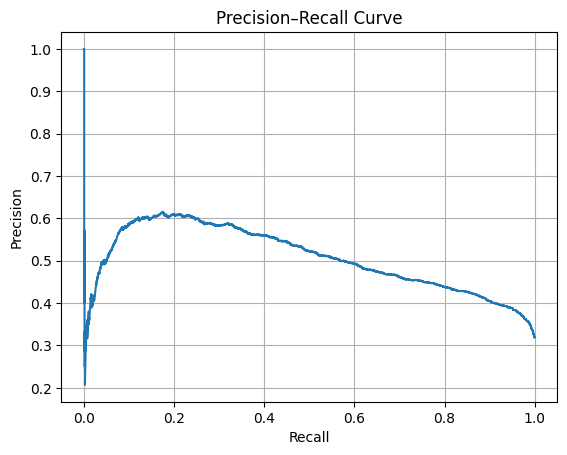

In [41]:
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.grid(True)
plt.show()

The Precision–Recall curve shows that the model can achieve high precision when recall is low, but capturing more defaulters requires accepting lower precision. This behavior is expected for early-stage PD prediction because defaulters and non-defaulters behave similarly within the first month. If needed, we can choose a new threshold based on business priorities. For now, this model will emphasize on high recall for risk monitoring.

### Conclusion

**Business Implications:**
- The model is suitable for early-stage risk flagging rather than final decisions. For example, identifying borrowers who may require proactive outreach, early servicing, or intervention based on their first 30 days of repayment behavior.
- Since the model achieves higher recall than precision, it is particularly useful for catching future defaulters early, even if it occasionally over-flags some non-defaulters.
- This allows the business to prioritize collections resources, assign borrowers to different monitoring tiers, and reduce losses through earlier engagement.

**Next Steps:**
- Monitor model drift by regularly tracking performance metrics as repayment behavior changes over time.
- Calibrate the decision threshold based on operational capacity.
- Run out-of-time validation to ensure generalization across different loan vintages.
- Enhance feature engineering by collecting additional income-related data, such as monthly income, employment stability, or debt-to-income ratio, which are known to be strong predictors of repayment capacity.

**Assumptions:**
- Input features (loan amount, lead type, payment regularity, etc.) are assumed to be accurate, complete, and consistently recorded across time.
- Borrower behavior within the first 30 days is assumed to be predictive of long-term repayment performance.

**Limitations:**
- Macroeconomic factors are not captured because the model does not incorporate broader economic conditions (e.g., interest rates, unemployment, inflation) that may affect approval behavior.
- The model relies solely on observed repayment data within the first 30 days, so any shocks or changes after that period are outside its predictive window.
- Any fraud risk not already flagged in underwriting is outside the scope of this model.
- ACH and payment system errors are treated as behavioral signals, even though some may be operational rather than borrower-driven.